# Exploratory Data Analysis: Retail Sales Dataset

**Objective:** Uncover patterns, customer behaviour trends, and actionable business insights from a multi-table retail sales dataset (Customers, Products, Stores, Transactions).

**Dataset source:** Kaggle — [Retail Sales Dataset](https://www.kaggle.com/datasets/buharishehu/retail-sales-dataset)

**Tech stack:** Python, pandas, matplotlib, seaborn


## 0. Setup

Place your downloaded `retail_sales_dataset.xlsx` file in a `data/` folder next to this notebook. It contains 4 sheets: `Customers`, `Products`, `Stores`, `Transactions`.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = "data/retail_sales_dataset.xlsx"


## 1. Load Dataset & Initial Inspection

We load all four tables, check their shape, dtypes, and null values before doing anything else.


In [4]:
customers = pd.read_excel(DATA_PATH, sheet_name="Customers")
products = pd.read_excel(DATA_PATH, sheet_name="Products")
stores = pd.read_excel(DATA_PATH, sheet_name="Stores")
transactions = pd.read_excel(DATA_PATH, sheet_name="Transactions")

for name, df in [("customers", customers), ("products", products),
                  ("stores", stores), ("transactions", transactions)]:
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    print(df.dtypes)
    print()


--- customers ---
Shape: (200, 7)
CustomerID            object
FirstName             object
LastName              object
Gender                object
BirthDate     datetime64[ns]
City                  object
JoinDate      datetime64[ns]
dtype: object

--- products ---
Shape: (50, 6)
ProductID       object
ProductName     object
Category        object
SubCategory     object
UnitPrice      float64
CostPrice      float64
dtype: object

--- stores ---
Shape: (5, 4)
StoreID      object
StoreName    object
City         object
Region       object
dtype: object

--- transactions ---
Shape: (5000, 8)
TransactionID            object
Date             datetime64[ns]
CustomerID               object
ProductID                object
StoreID                  object
Quantity                  int64
Discount                float64
PaymentMethod            object
dtype: object



In [5]:
# Null value check across all 4 tables
for name, df in [("customers", customers), ("products", products),
                  ("stores", stores), ("transactions", transactions)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f"--- {name} null counts ---")
    print(nulls if len(nulls) else "No nulls")
    print()


--- customers null counts ---
No nulls

--- products null counts ---
No nulls

--- stores null counts ---
No nulls

--- transactions null counts ---
No nulls



In [5]:
customers.head()

,CustomerID,FirstName,LastName,Gender,BirthDate,City,JoinDate
0,C001,Michael,Davis,M,1996-09-11,Osborneport,2022-09-25
1,C002,Michael,Miller,M,1959-08-18,New Gabrielleport,2020-11-03
2,C003,Carol,Hays,F,2005-04-19,Port Allen,2024-02-12
3,C004,Joseph,Ward,M,1992-06-16,East Edgarborough,2024-09-09
4,C005,Jamie,Salinas,M,1992-06-18,Port Kimberly,2022-02-24


In [6]:
products.head()

,ProductID,ProductName,Category,SubCategory,UnitPrice,CostPrice
0,P001,Like Camera,Electronics,Camera,1673.69,1323.38
1,P002,Audience Television,Electronics,Television,818.76,527.62
2,P003,Here Footwear,Fashion,Footwear,337.63,169.03
3,P004,Four Accessories,Fashion,Accessories,1853.77,1363.52
4,P005,Knowledge Bags,Fashion,Bags,1396.22,1004.09


In [7]:
stores.head()

,StoreID,StoreName,City,Region
0,S001,MegaMart Jimenezborough,Jimenezborough,South
1,S002,MegaMart Peckmouth,Peckmouth,East
2,S003,MegaMart New Michele,New Michele,West
3,S004,MegaMart Brianahaven,Brianahaven,North
4,S005,MegaMart Johnmouth,Johnmouth,East


In [8]:
transactions.head()

,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod
0,T00001,2024-06-18,C160,P014,S003,1,0.10,Bank Transfer
1,T00002,2023-11-02,C171,P030,S004,3,0.15,Bank Transfer
2,T00003,2024-03-28,C142,P002,S002,2,0.15,Mobile Money
3,T00004,2024-06-15,C174,P050,S002,5,0.10,Mobile Money
4,T00005,2024-08-29,C141,P036,S001,3,0.10,Credit Card


### Observation:  
* The Retail_Sales_Dataset contains 4 tables in star schema.  
* Tables are clean and no null values.
* Customers table contains 200 rows, Products table contains 50 rows, Stores table contains 5 rows and Transactions table contains 5000 rows.


## 2. Build the Analysis Table

We merge the fact table (`transactions`) with the three dimension tables, then engineer the core derived fields we'll need throughout: `Age`, `Tenure`, `Revenue`, `Cost`, `Profit`.


In [6]:
# Merge into one flat analysis table
df = transactions.merge(customers, on="CustomerID", how="left") \
                  .merge(products, on="ProductID", how="left") \
                  .merge(stores, on="StoreID", how="left")

print(df.shape)
df.head()


(5000, 22)


,TransactionID,Date,CustomerID,ProductID,StoreID,Quantity,Discount,PaymentMethod,FirstName,LastName,Gender,BirthDate,City_x,JoinDate,ProductName,Category,SubCategory,UnitPrice,CostPrice,StoreName,City_y,Region
0,T00001,2024-06-18,C160,P014,S003,1,0.10,Bank Transfer,Meagan,Macdonald,M,1991-09-10,Port Jacob,2021-10-27,Add Clothing,Fashion,Clothing,1342.75,797.94,MegaMart New Michele,New Michele,West
1,T00002,2023-11-02,C171,P030,S004,3,0.15,Bank Transfer,Christina,Dominguez,M,1993-03-15,Robertsborough,2025-07-28,National Watches,Fashion,Watches,29.24,15.28,MegaMart Brianahaven,Brianahaven,North
2,T00003,2024-03-28,C142,P002,S002,2,0.15,Mobile Money,Suzanne,Fox,M,2005-07-25,Joelborough,2020-12-27,Audience Television,Electronics,Television,818.76,527.62,MegaMart Peckmouth,Peckmouth,East
3,T00004,2024-06-15,C174,P050,S002,5,0.10,Mobile Money,Scott,Howell,M,2005-07-07,South Jennifer,2025-08-28,Maybe Footwear,Fashion,Footwear,1044.64,775.07,MegaMart Peckmouth,Peckmouth,East
4,T00005,2024-08-29,C141,P036,S001,3,0.10,Credit Card,Adam,Lucas,F,1978-08-06,Allisonmouth,2024-01-07,New Watches,Fashion,Watches,1501.46,1167.73,MegaMart Jimenezborough,Jimenezborough,South


In [7]:
# Parse dates
date_cols_transactions = ["Date"]
date_cols_customers = ["BirthDate", "JoinDate"]

for c in date_cols_transactions:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

for c in date_cols_customers:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

df[["Date", "BirthDate", "JoinDate"]].dtypes


Date         datetime64[ns]
BirthDate    datetime64[ns]
JoinDate     datetime64[ns]
dtype: object

In [8]:
# Feature engineering
today = df["Date"].max()  # use latest transaction date as reference point

df["Age"] = ((today - df["BirthDate"]).dt.days // 365).astype("Int64")
df["TenureDays"] = (df["Date"] - df["JoinDate"]).dt.days
df["TenureYears"] = (df["TenureDays"] / 365).round(1)

# Revenue / Cost / Profit — adjust column names below if yours differ
# assumes Transactions has Quantity and Discount, Products has UnitPrice and CostPrice
df["GrossRevenue"] = df["Quantity"] * df["UnitPrice"]
df["Discount"] = df["Discount"].fillna(0)
df["NetRevenue"] = df["GrossRevenue"] * (1 - df["Discount"])
df["TotalCost"] = df["Quantity"] * df["CostPrice"]
df["Profit"] = df["NetRevenue"] - df["TotalCost"]

df[["Age", "TenureYears", "GrossRevenue", "NetRevenue", "Profit"]].describe()


,Age,TenureYears,GrossRevenue,NetRevenue,Profit
count,5000.0,5000.000000,5000.000000,5000.000000,5000.000000
mean,44.4502,1.511040,3095.034344,2860.380629,765.262933
std,15.387855,1.569022,2435.648960,2265.958863,711.175525
min,18.0,-1.900000,25.570000,21.734500,2.684500
25%,31.0,0.300000,1128.840000,1043.154000,248.907875
50%,45.0,1.500000,2386.180000,2156.120000,555.111000
75%,59.0,2.800000,4865.440000,4451.305500,1066.502000
max,71.0,4.900000,9763.250000,9763.250000,4372.600000


### Observation:  
With the dates recorded in the tables, age and tenure of customerslooks realistic.  
No negative profit and no flags needed.

## 3. Descriptive Statistics

Mean, median, mode, and standard deviation for all numerical columns.


In [9]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

desc = df[num_cols].agg(["mean", "median", "std"]).T
desc["mode"] = df[num_cols].mode().iloc[0]
desc = desc[["mean", "median", "mode", "std"]]
desc


,mean,median,mode,std
Quantity,2.989800,3.000,2.0,1.409430
Discount,0.075880,0.100,0.15,0.056497
UnitPrice,1036.606538,1193.090,1134.8,589.316649
CostPrice,701.998512,794.800,675.1,426.686344
Age,44.450200,45.000,20.0,15.387855
TenureDays,551.574600,560.000,635.0,572.576061
TenureYears,1.511040,1.500,2.2,1.569022
GrossRevenue,3095.034344,2386.180,1879.08,2435.648960
NetRevenue,2860.380629,2156.120,4267.9095,2265.958863
TotalCost,2095.117696,1582.860,1004.56,1717.600926


### Observation: 

**High variability (std close to or exceeding mean):**  
*TenureDays are the most variable — std exceeding the mean. Profit is also highly variable — makes sense since profit is a product of quantity × price × discount × cost, so variability compounds from all four inputs.*  

**Skewed distributions (mean far from median):**  
*GrossRevenue, NetRevenue, TotalCost, and Profit are all right-skewed. UnitPrice and CostPrice are mildly left-skewed. Quantity, Age, and Tenure are roughly symmetric.*


## 4. Time Series Analysis

Monthly and quarterly sales trends.


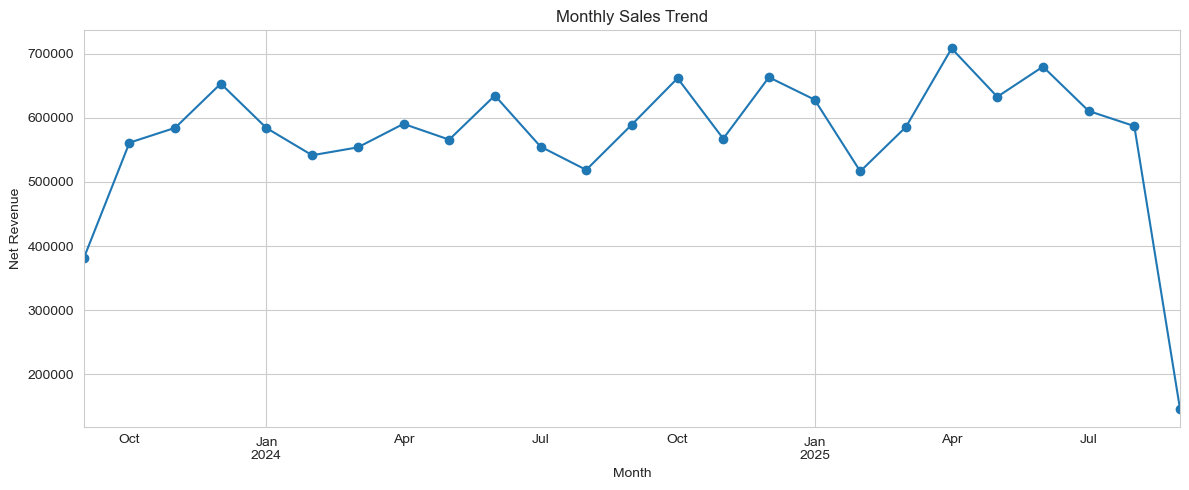

In [10]:
monthly_sales = df.set_index("Date").resample("ME")["NetRevenue"].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.tight_layout()
plt.show()


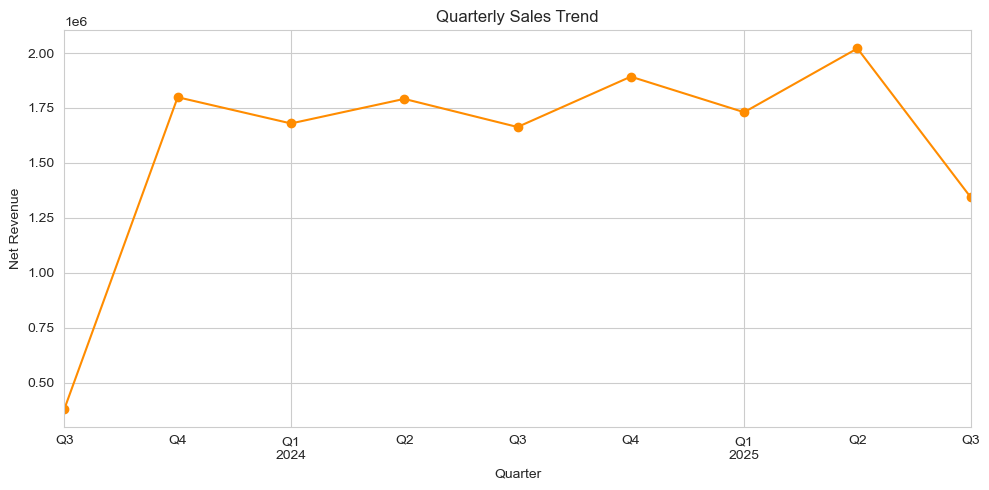

In [11]:
quarterly_sales = df.set_index("Date").resample("QE")["NetRevenue"].sum()

plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind="line", marker="o", color="darkorange")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Net Revenue")
plt.tight_layout()
plt.show()


### Observation: 

**Monthly Sales Trend:**
There's a visible oscillating pattern, shows some month-to-month volatility rather than a clean seasonal cycle. Shows a mild year-over-year growth signal, the highest point is April 2025.

**Quaterly Sales Trend:**
Q2 2025 is the peak - the strongest quarter in the dataset. There's no strong seasonal category.

## 5. Customer Demographics Analysis

Age group distribution and gender breakdown.


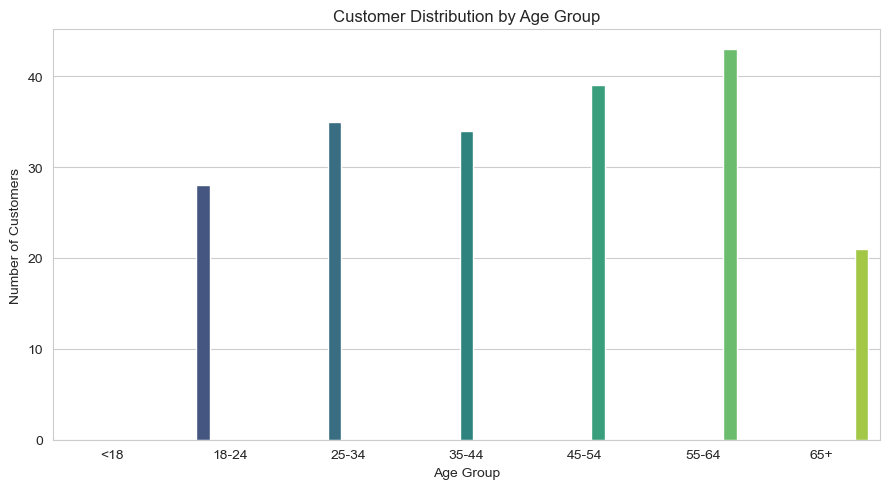

In [12]:
bins = [0, 18, 25, 35, 45, 55, 65, 120]
labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels, right=False)

plt.figure(figsize=(9, 5))
sns.countplot(data=df.drop_duplicates("CustomerID"), x="AgeGroup", order=labels, hue="AgeGroup", palette="viridis", legend=False)
plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


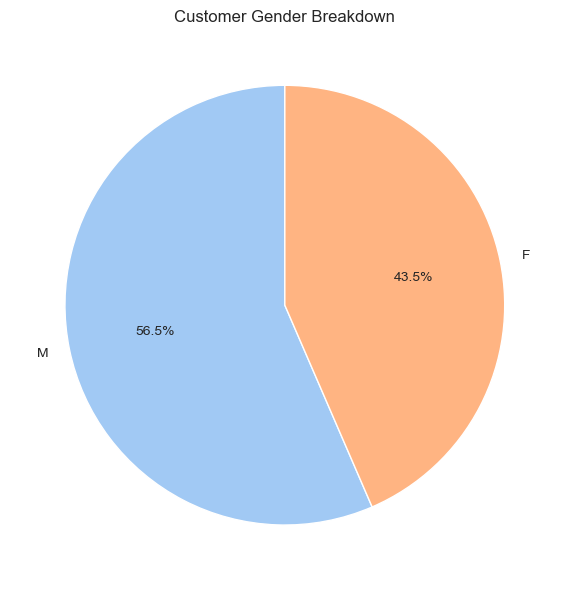

In [13]:
plt.figure(figsize=(6, 6))
gender_counts = df.drop_duplicates("CustomerID")["Gender"].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("pastel"))
plt.title("Customer Gender Breakdown")
plt.tight_layout()
plt.show()


### Observation: 

**Age group distribution:**  
* 55–64 is the dominant age group in the customer base.
* Each bracket from 18–24 through 55–64 is progressively larger, before dropping off sharply at 65+, the group <18 has zero customers understandable as minors.  

**Customer gender breakdown:**
* Shows Male majority (slightly higher than female)


## 6. Product Analysis

Top 10 best-selling products and revenue by category.


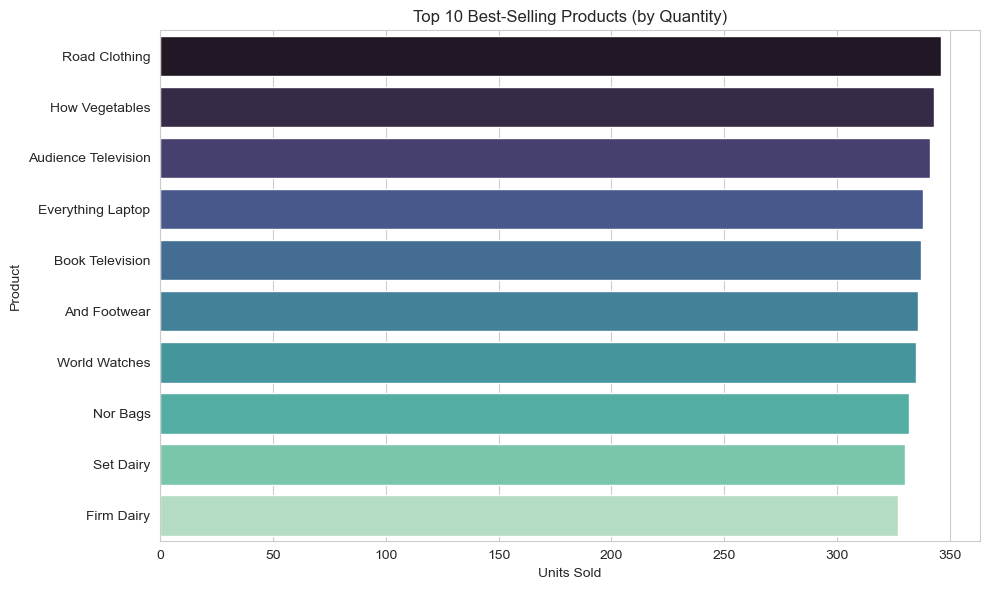

In [14]:
top_products = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="mako", legend=False)
plt.title("Top 10 Best-Selling Products (by Quantity)")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


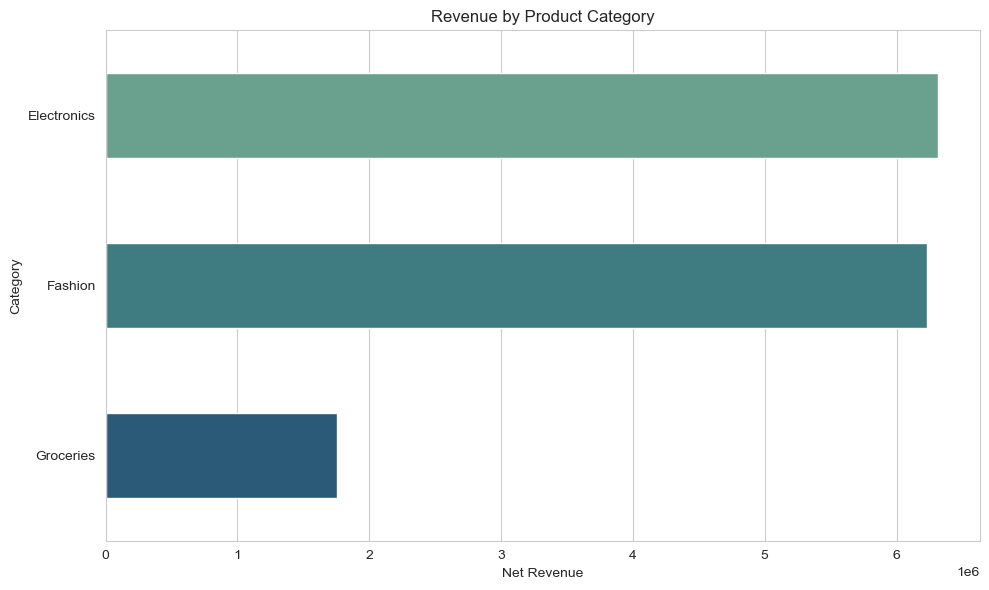

In [16]:
category_revenue = df.groupby("Category")["NetRevenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.values, y=category_revenue.index, hue=category_revenue.index, palette="crest", legend=False, width=0.5)
plt.title("Revenue by Product Category")
plt.xlabel("Net Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


### Observation: 
**High sales volume does not imply high revenue contribution.**  
* Even though grocery category items appear in the top 10 by units sold, Groceries as a whole is the lowest-revenue category.  
* Electronics generates the most revenue overall despite not dominating the units-sold chart.*  

### Limitations:
*Several product names in the chart look oddly generated. Product names appear auto-generated from the source dataset and are used only as unique identifiers, not literal product descriptions.*


## 7. Correlation Heatmap

Correlation matrix between numerical variables.


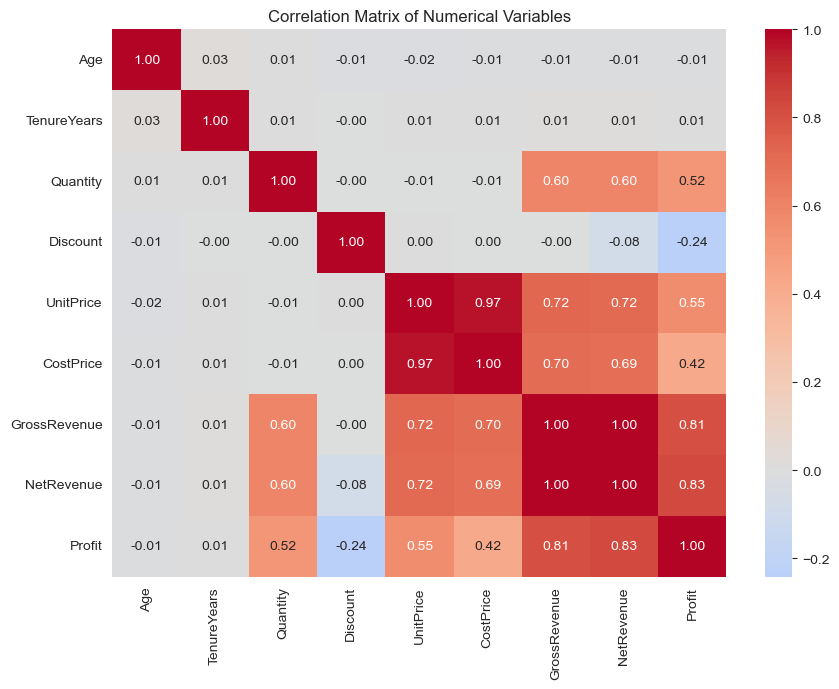

In [17]:
corr_cols = ["Age", "TenureYears", "Quantity", "Discount", "UnitPrice",
             "CostPrice", "GrossRevenue", "NetRevenue", "Profit"]
corr_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


### Observation: 

* **Discount correlates negatively with Profit** Discount's correlation with Revenue is much weaker, meaning discounts aren't meaningfully boosting how much customers buy, but they're clearly cutting into how much profit is retained on each sale.    
* **Quantity correlates moderately with Revenue** This suggests price, not volume, is the bigger lever on revenue in this dataset — a customer buying a few expensive items contributes more to revenue than one buying many cheap ones.  
* **Age and TenureYears are essentially uncorrelated with everything** It means customer age and loyalty tenure don't explain purchasing behavior in this dataset, which pushes back against any assumption that older or longer-tenured customers spend differently.  

## 8. Additional Insight: Discount Impact on Profit Margin by Payment Method

This isn't on a typical checklist but often reveals something non-obvious: whether certain payment methods are associated with heavier discounting, and how that plays out in margin.


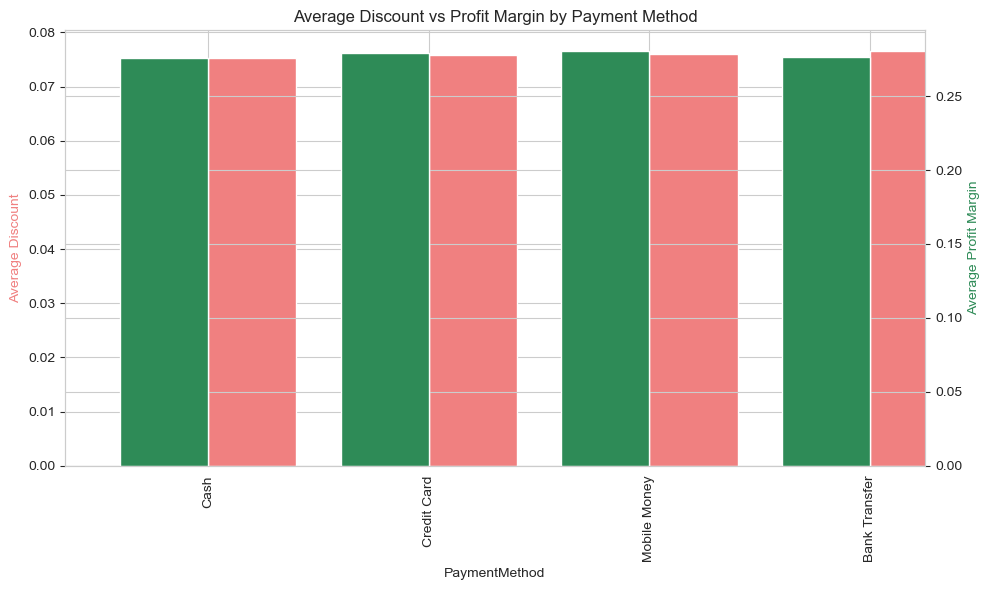

,AvgDiscount,AvgProfitMargin,TotalRevenue
PaymentMethod,,,
Cash,0.08,0.28,3676072.89
Credit Card,0.08,0.28,3673746.78
Mobile Money,0.08,0.28,3558433.48
Bank Transfer,0.08,0.28,3393650.00


In [28]:
df["ProfitMargin"] = df["Profit"] / df["NetRevenue"]

payment_summary = df.groupby("PaymentMethod").agg(
    AvgDiscount=("Discount", "mean"),
    AvgProfitMargin=("ProfitMargin", "mean"),
    TotalRevenue=("NetRevenue", "sum")
).sort_values("TotalRevenue", ascending=False)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

payment_summary["AvgDiscount"].plot(kind="bar", ax=ax1, color="lightcoral", position=0, width=0.4)
payment_summary["AvgProfitMargin"].plot(kind="bar", ax=ax2, color="seagreen", position=1, width=0.4)

ax1.set_ylabel("Average Discount", color="lightcoral")
ax2.set_ylabel("Average Profit Margin", color="seagreen")
ax1.set_title("Average Discount vs Profit Margin by Payment Method")
plt.tight_layout()
plt.show()

payment_summary


### Observation:
* **All four payment methods look identical** — 0.08 average discount and 0.28 average profit margin across the board. This means payment method itself has essentially no effect on how heavily transactions get discounted or how profitable they are.  
* **Mobile Money has the slightly highest average discount, while Bank Transfer has the slightly highest average profit margin** — but these gaps are minor.
* With TotalRevenue, Roughly a ₹280K gap between the top and bottom payment method. This gap is purely a volume/adoption effect, more customers are simply choosing Cash and Credit Card, not a profitability difference.  
* **No single payment method is a discount-policy red flag** This chart shows payment method is a neutral factor — none of the four methods is quietly eating margin or being over-discounted relative to the others.



## 9. Conclusion & Business Recommendations

### Key Findings

1. **Discounting is quietly eroding profit, not driving sales.** The correlation heatmap shows Discount has a **-0.24 correlation with Profit** but only **-0.08 with Net Revenue** - discounts aren't meaningfully increasing how much customers buy, they're just cutting into margin on sales that likely would have happened anyway.

2. **Revenue is price-driven, not volume-driven, and concentrated in two categories.** UnitPrice correlates more strongly with revenue (**0.72**) than Quantity does (**0.60**), and Electronics  and Fashion together generate over 3.5x the revenue of Groceries — despite grocery items appearing among the top 10 best-sellers by volume. High unit-volume categories aren't the same as high-revenue categories.

3. **Customer age, tenure, and payment method have almost no relationship to spending behavior.** Age and Tenure sit at correlations between **-0.02 and 0.03** with every financial metric, and payment method shows a flat **0.08 discount / 0.28 profit margin** across all four methods (Cash, Credit Card, Mobile Money, Bank Transfer) — the only real differentiator is a modest revenue-volume gap, not profitability.

---

### Actionable Recommendations

**1. Cap or restructure discounting policy**
> **Based on:** Correlation Matrix of Numerical Variables (Discount vs Profit = -0.24, Discount vs NetRevenue = -0.08)

**Action:** Since discounts show a meaningfully stronger negative pull on profit than any positive pull on revenue, introduce a discount ceiling (e.g., cap most promotions below 10%) and reserve deeper discounts for genuine slow-moving inventory rather than applying them broadly — broad discounting is measurably shrinking margin without a matching sales lift.

**2. Double down on Electronics and Fashion, re-price or bundle Groceries**
> **Based on:** Revenue by Product Category chart, Top 10 Best-Selling Products chart

**Action:** Prioritize marketing spend, shelf space, and inventory investment toward Electronics and Fashion, which drive the bulk of revenue despite moderate unit volume. For Groceries — which sells in comparable volume but contributes far less revenue — consider bundling grocery items with higher-margin products or adjusting price points, since current pricing isn't translating high demand into proportional revenue.

**3. Target marketing by revenue concentration, not just headcount, in the 55–64 age group**
> **Based on:** Customer Distribution by Age Group chart, Revenue by Age Group data

**Action:** The 55–64 bracket is both the largest customer segment (43 customers) and the top revenue contributor, but this is likely a volume effect given age has near-zero correlation with spending behavior. Rather than assuming this group is "high-value," calculate revenue-per-customer by age group before investing in age-targeted campaigns — if per-customer spend is flat across brackets, targeting should focus on acquiring more customers broadly rather than skewing campaigns toward any one age group.